<a href="https://colab.research.google.com/github/oisincam/quantum_circuits/blob/main/stim_5_qubit_code_with_7_total_qubits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction

I will be implementing the fault-tolerant extraction circuits from the following paper: [Quantum Error Correction with Only Two Extra Qubits](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.121.050502) for the $[[5,1,3]]_2$ code.

If you want to see it all in action, you can skip down to the 'Running and Analysis' ->'Running the Simulation' section. This contains a block which will run one simulation, and explain everything that is happening. (The very last cell of the notebook.)

##Imports

In [ ]:
!pip install stim~=1.14
!pip install galois
!pip install cairosvg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.1 MB/s eta 0:00:00


In [ ]:
import stim
import numpy as np
import galois
import cairosvg # for converting svg to png
from IPython.display import SVG, display #for displaying svg with custom colours
import random

##Helper Functions

###Representation Conversion

We can represent a stabilizer group using string, or as a stim object, or as a binary matrix.

In [ ]:
#convert a list of normal strings into stim pauli strings
def StringToStimPauli(list_of_strings):
  list_of_stimPaulis=[]
  for string in list_of_strings:
    list_of_stimPaulis.append(stim.PauliString(string))
  return list_of_stimPaulis


#Example
stabilizer=['XZZXI','IXZZX','XIXZZ','ZXIXZ']
StringToStimPauli(stabilizer)


[stim.PauliString("+XZZX_"),
 stim.PauliString("+_XZZX"),
 stim.PauliString("+X_XZZ"),
 stim.PauliString("+ZX_XZ")]

In [ ]:
#convert a list of stimPaulis to a galois matrix
def StimPaulisToMatrix(list_of_stimPaulis):
  matrix_rows=[]
  for stimPauli in list_of_stimPaulis:
    xpart,zpart=stimPauli.to_numpy() # use stim to convert binary, gives numpy arrays
    xpart=xpart*1
    zpart=zpart*1
    xlist=xpart.tolist()
    zlist=zpart.tolist()
    row=xlist+zlist #conccatenate the x and z part
    matrix_rows.append(row)
  GF2=galois.GF(2)
  matrix=GF2(matrix_rows) #make a matrix from the rows
  return matrix


#Example
StimPaulisToMatrix(StringToStimPauli(['IXXYZZ', 'XXYYII']))

GF([[0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1],
    [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0]], order=2)

In [ ]:
#convert a galois matrix to a list of stimPaulis
def MatrixToStimPaulis(matrix):
  m,two_n=matrix.shape
  n=int(two_n/2)
  list_stimPaulis=[]
  for i in range(0,m): # for each row of the matrix
    x_list=[]
    z_list=[]
    for j in range(0,n):#for each element in the row
      x_list.append(int(matrix[i][j]))
      z_list.append(int(matrix[i][n+j]))
    xs = np.array(x_list, dtype=np.bool_)
    zs = np.array(z_list, dtype=np.bool_)
    pauli = stim.PauliString.from_numpy(xs=xs, zs=zs, sign=1) #use x and z part to make stimPauli
    list_stimPaulis.append(pauli)
  return list_stimPaulis

#Example
GF2 = galois.GF(2)
A = GF2([[1,1,0,0,0,1,1,0]])
print(MatrixToStimPaulis(A))

[stim.PauliString("+XYZ_")]


In [ ]:
def StimPaulisToString(stimPauli):
  old_string = stimPauli.__str__()
  new_string = ''
  for i in range(1,len(old_string)):
    if old_string[i] == '_':
      new_string += 'I'
    else:
      new_string += old_string[i]

  return new_string


###Circuit Makers

In [ ]:
#create a circuit to naive measure a list of stimPaulis.
def Circuit_MeasurePaulis_OneAncilla(list_paulis):


  n=len(list_paulis[0]) # number of qubits implied by Pauli string, -1 for sign in front
  t=len(list_paulis)# number of operators to measure, thus number of ancilla

  qubits=range(0,n) #list of qubit indexes
  ancillas=range(n,n+t)# list of ancilla indexes

  c=stim.Circuit()

  for i in range(0,t): #for each operator/ancilla
    ancilla=n # we always use the nth ancilla
    c.append('R', [ancilla])
    c.append('H', [ancilla])

    for qubit in qubits: # for each qubit
      OP=list_paulis[i].__str__()[1+qubit] #pull out the operator on the qubit from string format

      if OP!='_': # it's j+1 since we skip the sign
        COP='C'+OP #make the controlled operation
        c.append(COP, [ancilla,qubit])

    c.append('H', [ancilla])
    c.append('M',[ancilla])
    c.append('TICK')

  return c

In [ ]:
#turns a pauli stim into a circuit that applies the Pauli stim
def PauliToCircuit(stimPauli,identities = False):
  circuit=stim.Circuit()
  n=len(stimPauli.__str__())
  for i in range(1,n):

    if identities == True: #optional arg to add identity blocks

      if stimPauli.__str__()[i]=='_':
        circuit.append('I', i-1) #i-1 since we skipped the + at start of string
      if stimPauli.__str__()[i]!='_':
        circuit.append(stimPauli.__str__()[i], i-1)
    else:
      if stimPauli.__str__()[i]!='_':
        circuit.append(stimPauli.__str__()[i], i-1)
  return circuit

In [ ]:
padding = stim.Circuit('''
I 7 7 7 7 7 7 7
I 0 1 2 3 4 5 6 7

I 7 7 7 7 7
'''
)


In [ ]:
TICK = stim.Circuit('TICK')

###Define the Flag measurement circuits

In [ ]:
flag_measure0=stim.Circuit('''
  RZ 5
  TICK
  RX 6
  TICK
  H 0
  TICK
  CNOT 0 5
  TICK
  H 0
  TICK
  CNOT 6 5
  TICK
  CNOT 1 5
  TICK
  CNOT 2 5
  TICK
  CNOT 6 5
  TICK
  H 3
  TICK
  CNOT 3 5
  TICK
  H 3
  TICK
  MZ 5
  TICK
  MX 6
''')

In [ ]:
flag_measure1=stim.Circuit('''
  RZ 5
  TICK
  RX 6
  TICK
  H 1
  TICK
  CNOT 1 5
  TICK
  H 1
  TICK
  CNOT 6 5
  TICK
  CNOT 2 5
  TICK
  CNOT 3 5
  TICK
  CNOT 6 5
  TICK
  H 4
  TICK
  CNOT 4 5
  TICK
  H 4
  TICK
  MZ 5
  TICK
  MX 6
''')

In [ ]:
flag_measure2=stim.Circuit('''
  RZ 5
  TICK
  RX 6
  TICK
  H 2
  TICK
  CNOT 2 5
  TICK
  H 2
  TICK
  CNOT 6 5
  TICK
  CNOT 3 5
  TICK
  CNOT 4 5
  TICK
  CNOT 6 5
  TICK
  H 0
  TICK
  CNOT 0 5
  TICK
  H 0
  TICK
  MZ 5
  TICK
  MX 6
''')

In [ ]:
flag_measure3=stim.Circuit('''
  RZ 5
  TICK
  RX 6
  TICK
  H 3
  TICK
  CNOT 3 5
  TICK
  H 3
  TICK
  CNOT 6 5
  TICK
  CNOT 4 5
  TICK
  CNOT 0 5
  TICK
  CNOT 6 5
  TICK
  H 1
  TICK
  CNOT 1 5
  TICK
  H 1
  TICK
  MZ 5
  TICK
  MX 6
''')

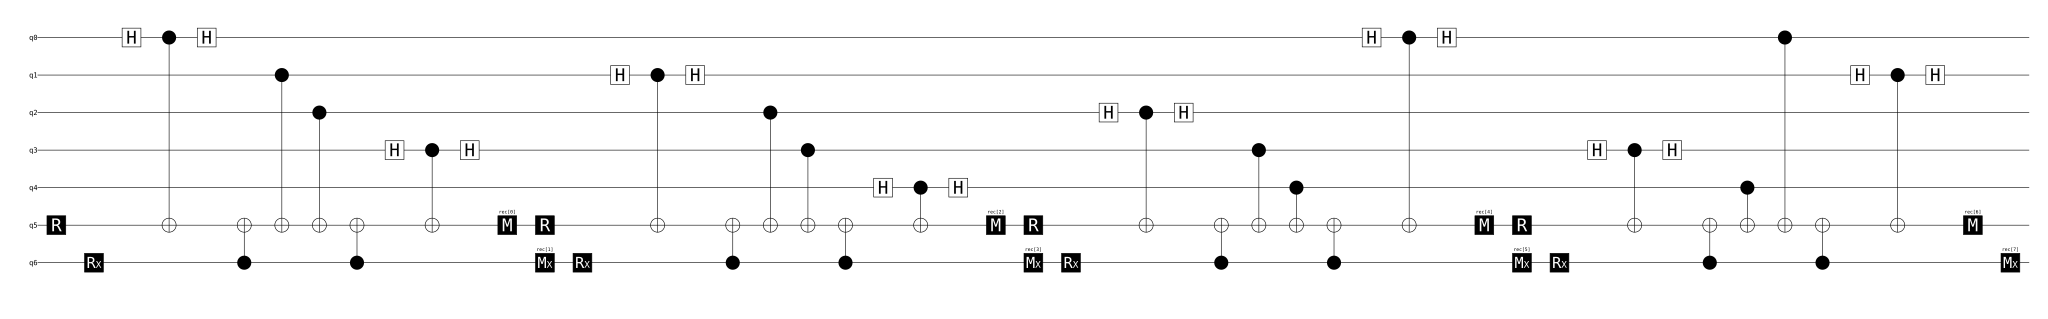

In [ ]:
(flag_measure0+flag_measure1+flag_measure2+flag_measure3).diagram('timeline-svg')

In [ ]:
list_flag_circuits = [flag_measure0, flag_measure1, flag_measure2, flag_measure3]

###Decoding

We will use a lookup decoder, stored as in a dictionary. We use the normal decoding table if no flag is raised. If the flag is raised, we use a decoding table that depends on the stage of the extraction process.

In [ ]:
#check if a stim pauli commutes or not with other stim paulis
def SyndromeExtract(stimPauli, list_stimPaulis):
  syndromes=[] # the syndrome is False if they commute
  for check in list_stimPaulis:
    syndromes.append(int(check.commutes(stimPauli)^True)) # we xor with True so that 'True' means 'anticommutes'
  return syndromes

#Example
SyndromeExtract(stim.PauliString('IXIZ'), StringToStimPauli(['XXXX', 'ZZZZ', 'XXZZ', 'ZZXX', 'IZIZ']))

[1, 1, 0, 0, 1]

In [ ]:
#this function generates a dictionary, syndromes are keys, operators are values
def SyndromeTableGenerator(list_stimPaulis,weight=0):
  n=list_stimPaulis[0].__len__() # number of data qubuts
  t=len(list_stimPaulis) # number of syndrome checks
  #we can loop over all paulis using this stim iterator:
  pauli_string_iterator = stim.PauliString.iter_all(
  num_qubits=n, #length
  min_weight=0,
  max_weight=weight,
  allowed_paulis="XYZ",) #allowed operators
  table={}
  count=0 # count the number of Pauli operators
  for p in pauli_string_iterator: #' for each pauli error
    count+=1
    syndrome = SyndromeExtract(p,list_stimPaulis) # compute the syndrome of the error
    table[tuple(syndrome)]=p #
  print('There are %d available syndromes to assign'%(2**t)) # each check contributes 1 syndrome bit
  print('There are %d Pauli operators of weight up to %d'%(count,weight))
  return table

In [ ]:
NoFlag_decoder_table = SyndromeTableGenerator(StringToStimPauli(['XZZXI','IXZZX','XIXZZ','ZXIXZ']), weight=1)

There are 16 available syndromes to assign
There are 16 Pauli operators of weight up to 1


In [ ]:
#We can ask the dictionary to tell us which Pauli has this syndrome.
NoFlag_decoder_table

{(0, 0, 0, 0): stim.PauliString("+_____"),
 (0, 0, 0, 1): stim.PauliString("+X____"),
 (1, 0, 1, 1): stim.PauliString("+Y____"),
 (1, 0, 1, 0): stim.PauliString("+Z____"),
 (1, 0, 0, 0): stim.PauliString("+_X___"),
 (1, 1, 0, 1): stim.PauliString("+_Y___"),
 (0, 1, 0, 1): stim.PauliString("+_Z___"),
 (1, 1, 0, 0): stim.PauliString("+__X__"),
 (1, 1, 1, 0): stim.PauliString("+__Y__"),
 (0, 0, 1, 0): stim.PauliString("+__Z__"),
 (0, 1, 1, 0): stim.PauliString("+___X_"),
 (1, 1, 1, 1): stim.PauliString("+___Y_"),
 (1, 0, 0, 1): stim.PauliString("+___Z_"),
 (0, 0, 1, 1): stim.PauliString("+____X"),
 (0, 1, 1, 1): stim.PauliString("+____Y"),
 (0, 1, 0, 0): stim.PauliString("+____Z")}

IF the flag is raised, we use a different decoding table, depending on which stage of extraction the flag was raised in.


In [ ]:
hook_errors0 = ['IIIII', 'IIZXI', 'IXZXI', 'IYZXI', 'IZZXI',
             'IIIXI', 'IIXXI', 'IIYXI', 'IIZXI']# list of possible hook errors
hook_errors1 = ['IIIII', 'IIIZX', 'IIXZX', 'IIYZX', 'IIZZX',
              'IIIIX', 'IIIXX', 'IIIYX', 'IIIZX']
hook_errors2 = ['IIIII', 'XIIIZ', 'XIIXZ', 'XIIYZ', 'XIIZZ',
              'XIIII', 'XIIIX', 'XIIIY', 'XIIIZ']
hook_errors3 = ['IIIII', 'ZXIII', 'ZXIIX', 'ZXIIY', 'ZXIIZ',
              'IXIII', 'XXIII', 'YXIII', 'ZXIII']
hook_errors = [hook_errors0, hook_errors1,hook_errors2, hook_errors3]
Flag_decoder_tables=[]
for i in range(0,len(hook_errors)):
  Flag_decoder_table = {}
  for p in StringToStimPauli(hook_errors[i]):
    syndrome = SyndromeExtract(p,StringToStimPauli(['XZZXI','IXZZX','XIXZZ','ZXIXZ']))
    Flag_decoder_table[tuple(syndrome)] = p
  Flag_decoder_tables.append(Flag_decoder_table)

In [ ]:
Flag_decoder_tables

[{(0, 0, 0, 0): stim.PauliString("+_____"),
  (0, 1, 0, 0): stim.PauliString("+__ZX_"),
  (1, 1, 0, 0): stim.PauliString("+_XZX_"),
  (1, 0, 0, 1): stim.PauliString("+_YZX_"),
  (0, 0, 0, 1): stim.PauliString("+_ZZX_"),
  (0, 1, 1, 0): stim.PauliString("+___X_"),
  (1, 0, 1, 0): stim.PauliString("+__XX_"),
  (1, 0, 0, 0): stim.PauliString("+__YX_")},
 {(0, 0, 0, 0): stim.PauliString("+_____"),
  (1, 0, 1, 0): stim.PauliString("+___ZX"),
  (0, 1, 1, 0): stim.PauliString("+__XZX"),
  (0, 1, 0, 0): stim.PauliString("+__YZX"),
  (1, 0, 0, 0): stim.PauliString("+__ZZX"),
  (0, 0, 1, 1): stim.PauliString("+____X"),
  (0, 1, 0, 1): stim.PauliString("+___XX"),
  (1, 1, 0, 0): stim.PauliString("+___YX")},
 {(0, 0, 0, 0): stim.PauliString("+_____"),
  (0, 1, 0, 1): stim.PauliString("+X___Z"),
  (0, 0, 1, 1): stim.PauliString("+X__XZ"),
  (1, 0, 1, 0): stim.PauliString("+X__YZ"),
  (1, 1, 0, 0): stim.PauliString("+X__ZZ"),
  (0, 0, 0, 1): stim.PauliString("+X____"),
  (0, 0, 1, 0): stim.PauliStri

###Error Propagation

In [ ]:
#Creates a list of circuit steps, as circuits
def CircuitToSteps(circuit):
  circuit_steps=[]
  for i  in range(len(circuit.__str__().split('\n')) ):
    circuit_steps.append(stim.Circuit(circuit.__str__().split('\n')[i]))
  return circuit_steps


In [ ]:
#this function returns a list of gate steps which are not TICKS or measures
def Gate_Steps(circuit):
  circuit_steps = CircuitToSteps(circuit)
  gate_steps=[] # a list of steps that are not ticks
  for i in range(0,len(circuit_steps)):
    if circuit_steps[i].__str__() != 'TICK'and circuit_steps[i].__str__()[0]!='M':
      gate_steps.append(i)
  return gate_steps

In [ ]:
#This will insert an error into a circuit, and we can see it propogate
#the step is the gate step, not the circuit step
def ErrorPropCircuit(circuit,erroneous_step,error):

  circuit_steps=CircuitToSteps(circuit)
  gate_steps = Gate_Steps(circuit)

  circuit_left_of_error=stim.Circuit()
  circuit_right_of_error=stim.Circuit()

  for i in range(0,erroneous_step+1):
    circuit_left_of_error += circuit_steps[gate_steps[i]]

  for i in range(erroneous_step+1, len(gate_steps)):
    circuit_right_of_error += circuit_steps[gate_steps[i]]

  error_circuit_before_prop = circuit_left_of_error + TICK + PauliToCircuit(error) + TICK + circuit_right_of_error

  propogated_error=error.after(circuit_right_of_error)

  error_circuit_after_prop = circuit_left_of_error + TICK + circuit_right_of_error + TICK +  PauliToCircuit(propogated_error)
  return (error_circuit_before_prop + TICK + padding + TICK + PauliToCircuit(propogated_error))

In [ ]:
#This function returns two lists, listing the 1 or 2 qubit gate steps respectively
def Gate_Extractor(circuit):
  circuit_steps = CircuitToSteps(circuit)
  gate_steps = Gate_Steps(circuit)
  OneQubit_gate_steps = []
  TwoQubit_gate_steps = []
  for i in gate_steps:
    if len(circuit_steps[i].__str__().split(' ')) == 2: # one space means 1 qubit involved
      OneQubit_gate_steps.append(i)
    elif len(circuit_steps[i].__str__().split(' ')) == 3: # two spaces means 2 qubits involved
      TwoQubit_gate_steps.append(i)
    else:
      raise TypeError('Each TICK can only involve 2 qubits, there must be no leading blanks on each line')
  return OneQubit_gate_steps, TwoQubit_gate_steps

In [ ]:
# This function takes in a stim circuit, and returns a list of possible gate errors
# The circuit must be broken into steps of only 1 and 2 qubit gates (ie no big CNOT lines)
#If multiple CNOTS, use ticks
def Gate_Errors(circuit):
  n = circuit.num_qubits

  circuit_steps = CircuitToSteps(circuit) # break the circuit into steps given by lines.
  gate_steps = Gate_Steps(circuit)


  # We split into 1 and 2 qubit gates

  OneQubit_gate_steps, TwoQubit_gate_steps = Gate_Extractor(circuit)

  #now we create the list of possible errors, along with circuit step
  blank_error = ''
  for i in range(0,n):
    blank_error+= 'I'
  Paulis='IXZY'
  gate_errors = []
  for i in OneQubit_gate_steps: # for each single qubit gate
    for pauli in Paulis: #for each single qubit pauli
      qubit = int(circuit_steps[i].__str__().split(' ')[1]) #which qubit is the gate operating on
      error = blank_error[:qubit] + pauli + blank_error[qubit+1:] # create the error string
      gate_errors.append( (int(i/2), error)) # we return the gate step, which is the circuit_step/2

  for i in TwoQubit_gate_steps:
    for pauli_one in Paulis:
      for pauli_two in Paulis: #we pick a pair of pauli operators

        qubit_one = int(circuit_steps[i].__str__().split(' ')[1]) # first qubit in gate
        qubit_two = int(circuit_steps[i].__str__().split(' ')[2]) # second qubit in gate

        if qubit_one < qubit_two:
          error = blank_error[:qubit_one] + pauli_one + blank_error[qubit_one+1:qubit_two] + pauli_two + blank_error[qubit_two+1:]
        elif qubit_two < qubit_one:
          error = blank_error[:qubit_two] + pauli_one + blank_error[qubit_two+1:qubit_one] + pauli_two + blank_error[qubit_one+1:]
        gate_errors.append((int(i/2),error)) # we return the gate step, which is the circuit_step/2

  return gate_errors




In [ ]:
circuit_steps = CircuitToSteps(list_flag_circuits[2])
gate_steps = Gate_Steps(list_flag_circuits[2])

In [ ]:
for i in Gate_Extractor(list_flag_circuits[0])[1]:
  print(circuit_steps[i])



CX 2 5
CX 6 5
CX 3 5
CX 4 5
CX 6 5
CX 0 5


In [ ]:
#This function takes in a stim circuit, and returns a list of triples, (step, gate_error, propagated_error)
def Enumerate_Propogated_Errors(circuit):
  gate_steps = Gate_Steps(circuit)
  circuit_steps = CircuitToSteps(circuit)
  gate_errors = Gate_Errors(circuit)#

  propagated_errors = []

  for pair in gate_errors:
    step, gate_error = pair
    left_of_error = stim.Circuit()
    right_of_error = stim.Circuit()

    for i in range(0,step+1):
      left_of_error += circuit_steps[gate_steps[i]]
    for i in range(step+1,len(gate_steps)):
      right_of_error += circuit_steps[gate_steps[i]]
    propagated_error = stim.PauliString(gate_error).after(right_of_error)

    propagated_errors.append((step,gate_error,propagated_error))

  return propagated_errors

###Stabilizer Equivalence

In [ ]:
#This function generates all elements of the stabilizer group
def GenerateStabilizerGroup(list_stim_paulis):
  full_stabilizer_group = []
  n = list_stim_paulis[0].__len__()
  t = len(list_stim_paulis)

  #prepare a blank pauli string
  stabilizer_string = ''
  for i in range(n):
    stabilizer_string += 'I'

  for i in range(2**t): #we sum over all binary strings of length t, to compute all possible stabilizer elements

    #we use i to create a binary string of length t
    digits = bin(i).split('b')[1] #this gives us the trailing digits of i; we need to pre append zeroes maybe
    if len(digits )<t:
      for k in range(0, t-len(digits )):
        digits  = '0' + digits

    coeffs = [int(d) for d in digits]
    #now we have a binary list of length t


    stabilizer_element = stim.PauliString(stabilizer_string) #we've created the identity pauli string
    #multiply in certain generator elements depending on which binary list we're in
    for j in range(0,t): # we check each coefficient to see if we should mutliply by that generator
      if coeffs[j] ==1:

        stabilizer_element= stabilizer_element*list_stim_paulis[j]
    full_stabilizer_group.append(stabilizer_element)

  return full_stabilizer_group

In [ ]:
#This function returns a minimum weight equivalent error
def MinimumWeightEquivalentError(stimPauli,list_stim_paulis, full_list = False ):
  full_stabilizer_group = GenerateStabilizerGroup(list_stim_paulis)
  weights = []
  equiv_errors = []
  for i in range(len(full_stabilizer_group)):
    equiv_error = stimPauli*full_stabilizer_group[i]
    equiv_errors.append(equiv_error)
    weights.append(equiv_error.weight)

  min_index = int(np.argmin(weights))
  if full_list == True:
    return equiv_errors[min_index], equiv_errors
  else:
    return equiv_errors[min_index]


###Visuals

In [ ]:
#this function edits the raw svg file to colour in X and Z gates
def ColourErrors(svg_string):
  lines = svg_string.splitlines() #split the svg file into lines
  output_lines = [] # output svg  lines

  for line in lines: # for each line
    if '>Z</text' in line: #if that line is drawing a Z symbol
      output_lines[-1] = output_lines[-1].replace('fill="white"', 'fill="#eb96ad"')#change box from previous line
    if '>X</text' in line: #if that line is drawing a X symbol
      output_lines[-1] = output_lines[-1].replace('fill="white"', 'fill="#F5AC20"')
    if '>Y</text' in line: #if that line is drawing a Y symbol
      output_lines[-1] = output_lines[-1].replace('fill="white"', 'fill="#faf86b"')



    output_lines.append(line)
  return '\n'.join(output_lines)



In [ ]:
# This function allows us to easily view a circuit
def ViewC(circuit, colours = False):
  raw_svg = circuit.diagram('timeline-svg').__str__()
  if colours == True:
    new_svg = ColourErrors(raw_svg)
    return print(display(SVG(new_svg)))
  else:
    return print(display(SVG(raw_svg)))

In [ ]:
#A function that takes in a stim circuit and saves a png of the svg-diagram
def CircuitToPNG(stim_circuit):
  svg_string = stim_circuit.diagram('timeline-svg').__str__()
  path = 'circuit_image.png'
  cairosvg.svg2png(bytestring=ColourErrors(svg_string).encode('utf-8'),write_to=path)

#Simulation Steps

##State Preparation

Since I only want to test out the syndrome extraction and decoding process, I will assume noiseless logical state preparation, for simplicity.

In [ ]:
# A function that will apply the state preparation to the simulator
def StatePreparation(simulator,timeline_segment):

  stabilizer=['XZZXI','IXZZX','XIXZZ','ZXIXZ']#stabilizers
  LogicalZ=['ZZZZZ']
  LogicalX=['XXXXX']

  #Suitable operators to fix the signs of the Fullstabilizer
  #The ith operator anticommutes with Fullstabilizer i
  Fixers=['IZIZZ','IIIIZ','ZZIZZ','IZIIZ','ZIIZX']

  FullStabilizer=stabilizer+LogicalZ

  n=len(stabilizer[1])#number of logical qubits
  t=len(stabilizer)#number of measurements= number of required ancillas
  k=n-t

  circuit_naive_measure_fullstab = Circuit_MeasurePaulis_OneAncilla(StringToStimPauli(FullStabilizer))#a circuit to measure the full stabilizer
  simulator.do(circuit_naive_measure_fullstab)
  timeline_segment += circuit_naive_measure_fullstab

  #Now we want to apply the fixes, based on the current measurement record
  circuit_StatePrepFix=stim.Circuit()
  for i in range(0,len(FullStabilizer)):
    if simulator.current_measurement_record()[-5:][i]==True:
      for qubit in range(0,n):
        circuit_StatePrepFix.append(Fixers[i][qubit],qubit)
  circuit_StatePrepFix.diagram()

  simulator.do(circuit_StatePrepFix)
  timeline_segment += circuit_StatePrepFix


##Noise on Data


In [ ]:
def DataNoise(simulator, timeline,p):
  data_error =''
  for i in range(0,5): # for each qubit
    qubit_error_roll = random.uniform(0,1)
    if qubit_error_roll < p: # check if noise happened
      data_error += random.choice('XYZ')# uniform Pauli Noise
    else:
      data_error+= 'I'
  #We can force a specific data error if we want
  # data_error = 'ZZZZZ'
  # data_error = 'IIIII'
  # data_error = 'ZIIII'


  data_noise_circuit = PauliToCircuit(stim.PauliString(data_error), identities = True)
  s.do(data_noise_circuit)
  timeline += data_noise_circuit
  return stim.PauliString(data_error)




##Syndrome Extraction

###Noise in Syndrome Extraction

The syndrome extraction circuit we are using is fault-tolerant; if one component of the syndrome extraction process fails, we can still successfully decode. To model this, we will randomly insert a gate failure to one of the syndrome extraction circuits, using the helper functions. The gate failure may not appear, if the data error means we naive extract the four syndromes early on.

In [ ]:
#this function takes in our list of flagged circuits, and inserts exactly 1 gate error in one of them
def GateFailure(list_flag_circuits):

  flagged_failure_number = random.randint(0,3) # which syndrome extraction circuit will we insert a gate failure into

  #
  flagged_failure_number = 2 # force a specific circuit to have a gate failure
  #

  circuit_steps = CircuitToSteps(list_flag_circuits[flagged_failure_number])
  gate_steps = Gate_Steps(list_flag_circuits[flagged_failure_number])


  gate_failure = random.choice(Enumerate_Propogated_Errors(list_flag_circuits[flagged_failure_number]))

  #
  # gate_failure = Enumerate_Propogated_Errors(list_flag_circuits[flagged_failure_number])[50] # force a specific gate failure
  # gate_failure = Enumerate_Propogated_Errors(list_flag_circuits[flagged_failure_number])[66] # force a specific gate failure
  #

  circuit_error_step = gate_steps[gate_failure[0]]

  circuit_left_of_error=stim.Circuit()
  circuit_right_of_error=stim.Circuit()

  for i in range(0,circuit_error_step+1):
    circuit_left_of_error += circuit_steps[i]

  for i in range(circuit_error_step+1, len(circuit_steps)):
    circuit_right_of_error += circuit_steps[i]

  error_circuit = circuit_left_of_error + TICK + PauliToCircuit(stim.PauliString(gate_failure[1]), identities= True) + TICK + circuit_right_of_error

  list_flag_circuits[flagged_failure_number] = error_circuit
  return flagged_failure_number, gate_failure, list_flag_circuits

###Syndrome Extraction Function

In [ ]:
def FlaggedSyndromeExtraction(simulator,timeline):

  circuit_naive_measure_stab = Circuit_MeasurePaulis_OneAncilla(StringToStimPauli(stabilizer))

  flag = False
  stage=0
  fragile_syndromes=[]
  while flag == False and stage <= 3:
    simulator.do(list_flag_circuits[stage])# make the flagged measurement
    timeline+=list_flag_circuits[stage]
    syndrome,flag=s.current_measurement_record()[-2:] # record the outcomes
    fragile_syndromes.append(syndrome) #  we keep track of syndromes in case of success
    if flag==True:# if the flag was raised
      timeline += padding
      simulator.do(circuit_naive_measure_stab) # we non-FT measure the 4 stabilizers
      useful_syndromes = tuple([int(i) for i in s.current_measurement_record()[-4:]])
      timeline+=circuit_naive_measure_stab
      break #don't do anything else

    elif syndrome==True: # if the syndrome is reported
      simulator.do(circuit_naive_measure_stab) # we non-FT measure the 4 stabilizers
      useful_syndromes = tuple([int(i) for i in s.current_measurement_record()[-4:]])# the decoding syndromes are the last 4 measured syndromes
      timeline += padding
      timeline+=circuit_naive_measure_stab
      break # don't do anything else
    stage+=1
  if flag == False and syndrome == False:
    useful_syndromes = tuple([int(i) for i in fragile_syndromes]) #if we don't raise flag or syndrome, use the fragile syndromes

  return flag, useful_syndromes, stage





##Decoding

In [ ]:
def Correction(simulator,timeline):

  if flag == False: #if the flag was not raised, we decode to minimum weight error
    correction = NoFlag_decoder_table[useful_syndromes]

  else: # if flag was raised, we use special decoding table
    if useful_syndromes not in Flag_decoder_tables[stage].keys(): #if the syndrome has not been assigned
      correction = NoFlag_decoder_table[useful_syndromes]
      print('This syndrome has no assigned error, so I used the other table')


    else:
      correction = Flag_decoder_tables[stage][useful_syndromes]


  simulator.do(PauliToCircuit(correction))
  timeline += PauliToCircuit(correction, identities= True)

  return correction, useful_syndromes

#Running and Analysis

Let's put everything together, and run this simulation a few times to see error-correction in action!

##Running the Simulation

The simulation we run is as follows:

*   We noiselessly prepare the logical $0$ state of the $[[5,1,3]]_2$ qubit code (state preparation).
*   After state preparation, we randomly apply an error to the data qubits. For each qubit, we roll a number in the interval $x \in [0,1]$; if the number $x < 0.1$ then we randomly select an $X,Y$ or $Z$ error and apply it to the qubit.
* Before beginning the flagged syndrome extraction process, we always select 1 gate from the entire process, and declare that it will fail. After using this gate in the circuit, for each qubit that the gate operates on we randomly select from $I,X,Y,Z$ and apply the error to the qubit.
* We then begin the flagged syndrome extraction process; if either a syndrome or flag is raised, we stop and measure all 4 stabilizer generators using non-fault tolerant circuits.

* We take the extracted syndrome, and feed it to one of 5 decoders, depending on if the flag was raised and at what stage.

* Then we apply a correction based on the decoder result.



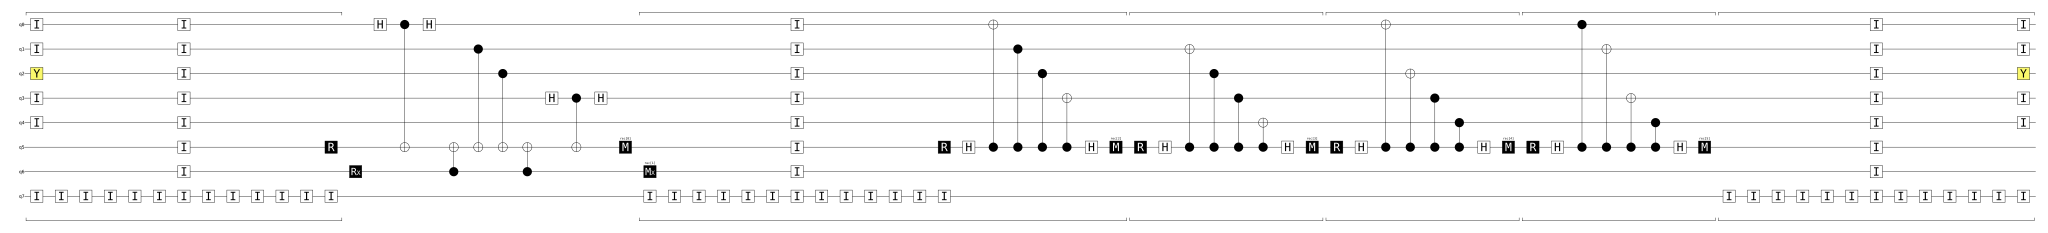

None
After state preparation, we introduced error IIYII.
Was the flag raised: False
We exited the protocol after circuit 1, and measured all 4 syndromes again.
The syndrome used for decoding was (1, 1, 1, 0)
We applied correction  IIYII.
The remaining error is IIIII.
This error is equivalent to IIIII.


In [ ]:
s = stim.TableauSimulator() #Initilaise the simulator
timeline = stim.Circuit() #Initilise the main timeline

#State Preparation
timeline_stateprep=stim.Circuit() # The state preparation timeline
StatePreparation(s,timeline_stateprep)# Run state preparation procedure
# timeline += timeline_stateprep #let's ignore state prep for now
# timeline += padding

#Data Noise
timeline_datanoise = stim.Circuit()# The data noise timeline
data_error = DataNoise(s,timeline_datanoise,0.1)#Run the Data Noise procedure
timeline += timeline_datanoise
timeline += padding

#Define Flag Circuit
list_flag_circuits = [flag_measure0, flag_measure1, flag_measure2, flag_measure3]

#Gate Noise
flagged_failure_number, gate_failure, list_flag_circuits = GateFailure(list_flag_circuits)
#Syndrome Extraction
timeline_syndromeextraction = stim.Circuit() #Syndrome Extraction Timeline
flag, useful_syndromes, stage = FlaggedSyndromeExtraction(s,timeline_syndromeextraction)#Run the Syndrome Extraction Procedure
timeline+=timeline_syndromeextraction
timeline += padding

#Decoding and Correction
timeline_decoding = stim.Circuit()
correction, useful_syndromes = Correction(s,timeline_decoding)
timeline+=timeline_decoding

ViewC(timeline, colours = True)
#Analysis
print('After state preparation, we introduced error %s.'%(StimPaulisToString(data_error) ))
if stage >= flagged_failure_number:
  print('During syndrome extraction, circuit %d had a failure on gate %d .'%(flagged_failure_number, gate_failure[0]))
  print('This introduced error %s, which propagated to data error %s.'%(gate_failure[1], StimPaulisToString(gate_failure[2])[0:5]))
print('Was the flag raised: %s'%(flag))
if stage == 4:
  print('We completed the flagged syndrome protocol without exiting')
else:
  print('We exited the protocol after circuit %d, and measured all 4 syndromes again.'%(stage+1))
print('The syndrome used for decoding was %s'%(str(useful_syndromes)))
print('We applied correction  %s.'%(StimPaulisToString(correction) ))

#Compute the remaining error
final_error = data_error

if stage >= flagged_failure_number:
  final_error = final_error*stim.PauliString(StimPaulisToString(gate_failure[2])[0:5]) # multiply by the introduced error

final_error = final_error*correction # multiply by correction applied

equiv_final_error = MinimumWeightEquivalentError(final_error, StringToStimPauli(stabilizer))

print('The remaining error is %s.'%(StimPaulisToString(final_error)))
print('This error is equivalent to %s.'%(StimPaulisToString(equiv_final_error)))

In [ ]:
gate_failure

(4, 'IIIIIIX', stim.PauliString("+______X"))